In [19]:
import numpy as np
import os
import xarray as xr
import Ngl
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, HourLocator, date2num, num2date

# vertical_int = np.trapz(integrand, x=ds.lev, axis=1)

# constants
g = 9.81

DIR = '/glade/derecho/scratch/nforcone/CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Perturbation/run'
FILE = 'CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Perturbation.cam.h0a.0001-01-31-00000.nc'
ds = xr.open_dataset(os.path.join(DIR, FILE), decode_cf=False)
ds

<xarray.Dataset> Size: 1GB
Dimensions:       (lat: 91, lon: 180, lev: 30, ilev: 31, trop_pref: 30,
                   trop_prefi: 31, time: 36, nbnd: 2, chars: 8)
Coordinates:
  * lat           (lat) float64 728B -90.0 -88.0 -86.0 -84.0 ... 86.0 88.0 90.0
  * lon           (lon) float64 1kB 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * lev           (lev) float64 240B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 248B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * trop_pref     (trop_pref) float64 240B 3.643 7.595 14.36 ... 976.3 992.6
  * trop_prefi    (trop_prefi) float64 248B 2.255 5.032 10.16 ... 985.1 1e+03
  * time          (time) float64 288B 15.0 45.0 75.0 ... 1.035e+03 1.065e+03
Dimensions without coordinates: nbnd, chars
Data variables: (12/44)
    w             (lat) float64 728B ...
    hyam          (lev) float64 240B ...
    hybm          (lev) float64 240B ...
    hyai          (ilev) float64 248B ...
    hybi          (ilev) float64 248B ...
    date          (time) int32 144B ...
    ...            ...
    VV            (time, lev, lat, lon) float32 71MB ...
    Z3            (time, lev, lat, lon) float32 71MB ...
    ZZ            (time, lev, lat, lon) float32 71MB ...
    TT            (time, lev, lat, lon) float32 71MB ...
    VQ            (time, lev, lat, lon) float32 71MB ...
    QQ            (time, lev, lat, lon) float32 71MB ...
Attributes:
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              CAM_6_4_025_20240829_ne16_ne16_mg17_Aqua_Perturbation
    logname:           nforcone
    host:              dec2411
    initial_file:      /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/s...
    topography_file:   bnd_topo
    model_doi_url:     not_set
    time_period_freq:  day_30

$$\overline{vT}=\overline{v}\overline{T}+\overline{v'T'}$$

overbar is time mean, ' is time anomaly

$$[vT]=[v][T]+[v^*T^*]$$

[ ] is zonal mean, * is zonal anomaly

## Kinetic Energy (fix units!)

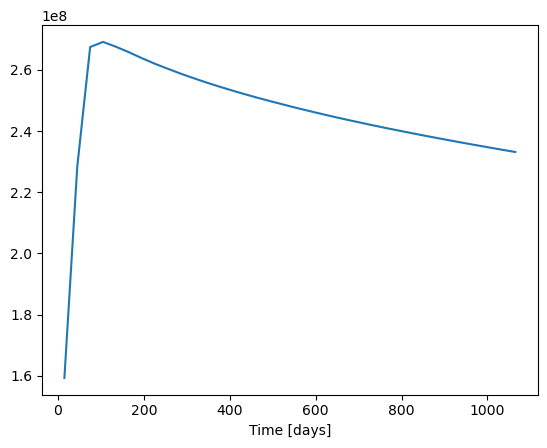

In [25]:
U = ds.U
V = ds.V
lat = ds.lat
time = ds.time
integrand = 0.5 * (U**2 + V**2)

# integrate over model level
integrate1 = integrand.integrate(coord='lev') / (2 * g)

# integrate over latitude
integrate2 = (np.cos(np.deg2rad(lat)) * integrate1).integrate(coord='lat')

# integrate over longitude
integrate3 = integrate2.integrate(coord='lon')

plt.figure(1)
plt.xlabel('Time [days]')
plt.plot(time, integrate3)